# Sales Data Analysis
This project analyzes e-commerce sales data to identify trends, top-selling products, and customer purchasing behavior using Python and data visualization.

## Import Libraries
Import the necessary Python libraries for data analysis and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os
files = os.listdir("../data")

all_data = pd.DataFrame()

for file in files:
    if file.endswith(".csv") and file != "sales_data.csv":
        df = pd.read_csv("../data/" + file)
        all_data = pd.concat([all_data, df])

all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


## Data Loading
Load and combine all monthly sales datasets into a single dataframe.

In [2]:
files = os.listdir("../data")
files

['Sales_April_2019.csv',
 'Sales_August_2019.csv',
 'sales_data.csv',
 'Sales_December_2019.csv',
 'Sales_February_2019.csv',
 'Sales_January_2019.csv',
 'Sales_July_2019.csv',
 'Sales_June_2019.csv',
 'Sales_March_2019.csv',
 'Sales_May_2019.csv',
 'Sales_November_2019.csv',
 'Sales_October_2019.csv',
 'Sales_September_2019.csv']

In [3]:
all_data.shape

(186850, 6)

In [4]:
all_data.to_csv("../data/sales_data.csv", index=False)

## Data Cleaning
Clean the dataset by removing missing values and incorrect rows, and converting columns to appropriate data types.

In [5]:
all_data.isnull().sum()

Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64

In [6]:
all_data = all_data.dropna()

In [7]:
all_data = all_data[all_data['Order Date'] != 'Order Date']

In [9]:
all_data['Quantity Ordered'] = pd.to_numeric(all_data['Quantity Ordered'])
all_data['Price Each'] = pd.to_numeric(all_data['Price Each'])

## Feature Engineering
Create additional features such as Sales, Month, City, and Hour to enable deeper analysis.

In [10]:
all_data['Sales'] = all_data['Quantity Ordered'] * all_data['Price Each']

In [11]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",23.90
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",99.99
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",600.00
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",11.99
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",11.99


In [12]:
all_data['Month'] = all_data['Order Date'].str[0:2]

In [13]:
all_data['Month'] = all_data['Month'].astype('int32')

In [14]:
all_data.head()

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales,Month
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001",23.90,4
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215",99.99,4
3,176560,Google Phone,1,600.00,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",600.00,4
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001",11.99,4
5,176561,Wired Headphones,1,11.99,04/30/19 09:27,"333 8th St, Los Angeles, CA 90001",11.99,4


## Monthly Sales Analysis
Analyze how sales vary across different months to identify seasonal trends.

In [15]:
monthly_sales = all_data.groupby('Month')['Sales'].sum()

monthly_sales

Month
1     1822256.73
2     2202022.42
3     2807100.38
4     3390670.24
5     3152606.75
6     2577802.26
7     2647775.76
8     2244467.88
9     2097560.13
10    3736726.88
11    3199603.20
12    4613443.34
Name: Sales, dtype: float64

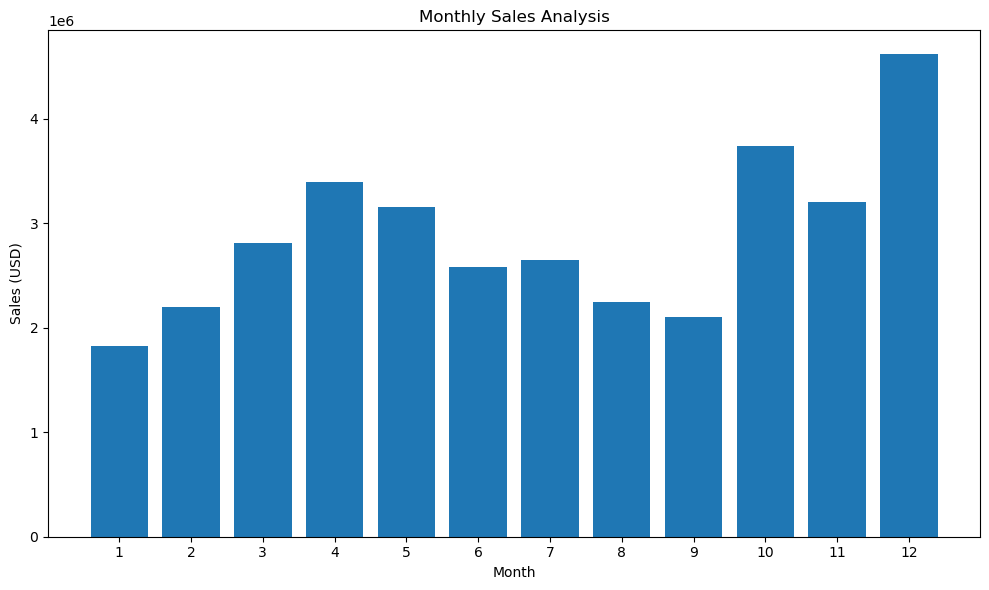

In [17]:
plt.figure(figsize=(10,6))

months = range(1,13)

plt.bar(months, monthly_sales)

plt.xlabel("Month")
plt.ylabel("Sales (USD)")
plt.title("Monthly Sales Analysis")

plt.xticks(months)

plt.tight_layout()

plt.savefig("../images/monthly_sales.png")   # save BEFORE show

plt.show()

## Product Sales Analysis
Determine which products are sold the most and contribute significantly to overall revenue.

In [18]:
product_sales = all_data.groupby('Product')['Quantity Ordered'].sum()

product_sales

Product
20in Monitor                   4129
27in 4K Gaming Monitor         6244
27in FHD Monitor               7550
34in Ultrawide Monitor         6199
AA Batteries (4-pack)         27635
AAA Batteries (4-pack)        31017
Apple Airpods Headphones      15661
Bose SoundSport Headphones    13457
Flatscreen TV                  4819
Google Phone                   5532
LG Dryer                        646
LG Washing Machine              666
Lightning Charging Cable      23217
Macbook Pro Laptop             4728
ThinkPad Laptop                4130
USB-C Charging Cable          23975
Vareebadd Phone                2068
Wired Headphones              20557
iPhone                         6849
Name: Quantity Ordered, dtype: int64

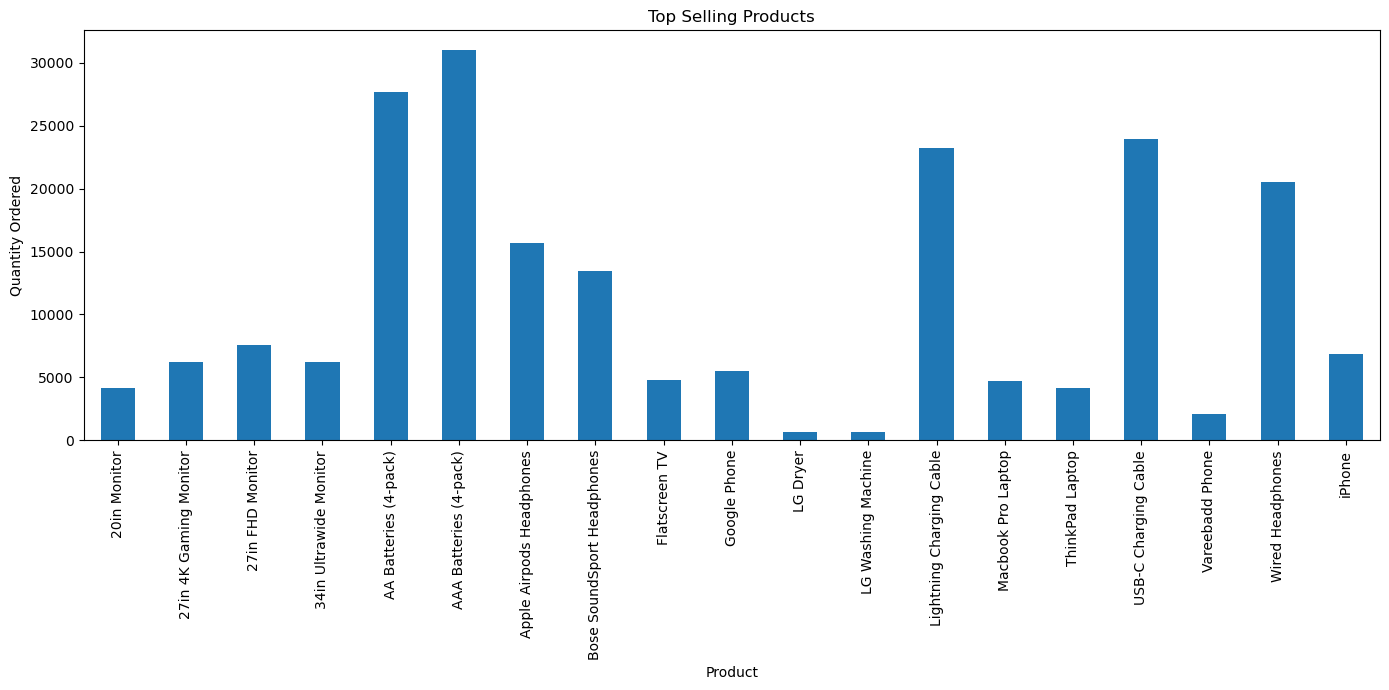

In [19]:
plt.figure(figsize=(14,7))

products = all_data.groupby('Product')['Quantity Ordered'].sum()

products.plot(kind='bar')

plt.xlabel("Product")
plt.ylabel("Quantity Ordered")
plt.title("Top Selling Products")
plt.xticks(rotation=90)

plt.tight_layout()

plt.savefig("../images/product_sales.png")

plt.show()

## Sales by City
Identify which cities generate the highest sales revenue.

In [20]:
all_data['City'] = all_data['Purchase Address'].apply(lambda x: x.split(',')[1])

In [21]:
all_data[['City', 'Purchase Address']].head()

,City,Purchase Address
0,Dallas,"917 1st St, Dallas, TX 75001"
2,Boston,"682 Chestnut St, Boston, MA 02215"
3,Los Angeles,"669 Spruce St, Los Angeles, CA 90001"
4,Los Angeles,"669 Spruce St, Los Angeles, CA 90001"
5,Los Angeles,"333 8th St, Los Angeles, CA 90001"


In [22]:
city_sales = all_data.groupby('City')['Sales'].sum()
city_sales

City
Atlanta          2795498.58
Austin           1819581.75
Boston           3661642.01
Dallas           2767975.40
Los Angeles      5452570.80
New York City    4664317.43
Portland         2320490.61
San Francisco    8262203.91
Seattle          2747755.48
Name: Sales, dtype: float64

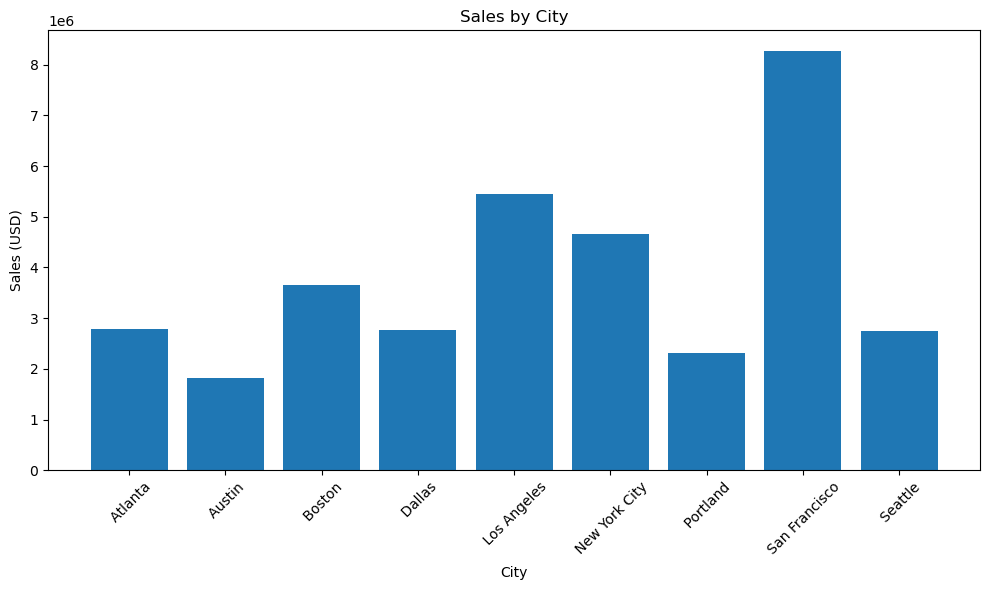

In [23]:
plt.figure(figsize=(10,6))

cities = [city for city, df in all_data.groupby('City')]

plt.bar(cities, city_sales)

plt.xlabel("City")
plt.ylabel("Sales (USD)")
plt.title("Sales by City")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../images/city_sales.png")

plt.show()

## Orders by Hour
Analyze customer purchasing patterns throughout the day.

In [24]:
all_data['Order Date'] = pd.to_datetime(all_data['Order Date'])

C:\Users\Urvashi Pandey\AppData\Local\Temp\ipykernel_17936\3842191188.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  all_data['Order Date'] = pd.to_datetime(all_data['Order Date'])


In [25]:
all_data['Hour'] = all_data['Order Date'].dt.hour

In [26]:
all_data[['Order Date','Hour']].head()

,Order Date,Hour
0,2019-04-19 08:46:00,8
2,2019-04-07 22:30:00,22
3,2019-04-12 14:38:00,14
4,2019-04-12 14:38:00,14
5,2019-04-30 09:27:00,9


In [27]:
hours = all_data.groupby('Hour').count()
hours

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address,Sales,Month,City
Hour,,,,,,,,,
0,3910,3910,3910,3910,3910,3910,3910,3910,3910
1,2350,2350,2350,2350,2350,2350,2350,2350,2350
2,1243,1243,1243,1243,1243,1243,1243,1243,1243
3,831,831,831,831,831,831,831,831,831
4,854,854,854,854,854,854,854,854,854
5,1321,1321,1321,1321,1321,1321,1321,1321,1321
6,2482,2482,2482,2482,2482,2482,2482,2482,2482
7,4011,4011,4011,4011,4011,4011,4011,4011,4011
8,6256,6256,6256,6256,6256,6256,6256,6256,6256


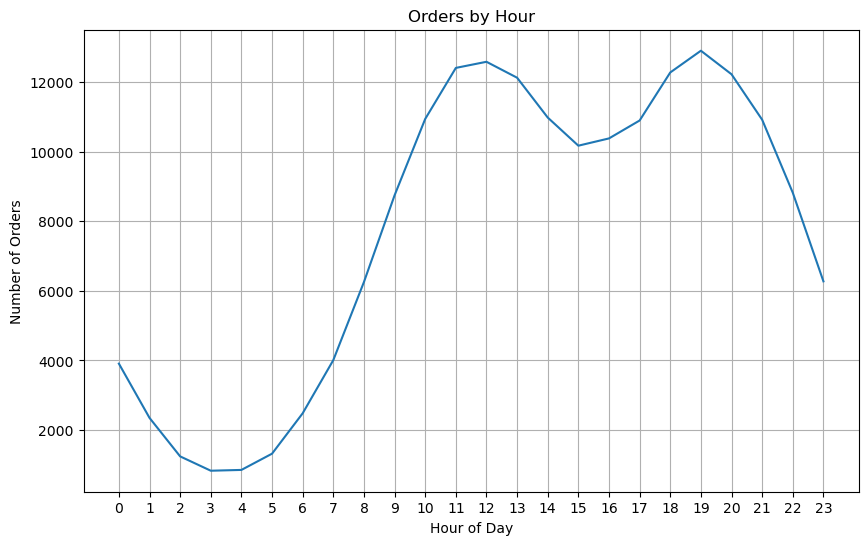

In [28]:
plt.figure(figsize=(10,6))

plt.plot(hours.index, hours['Order ID'])

plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.title("Orders by Hour")

plt.xticks(range(0,24))

plt.grid()

plt.savefig("../images/orders_by_hour.png")

plt.show()